# LeetCode #724: Find Pivot Index

https://leetcode.com/problems/find-pivot-index/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(1)$ |
| **Optimal: Prefix Sum** | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
For each candidate pivot index $i$, iterate over all elements to the left for their sum and all elements to the right for their sum. Compare and return $i$ if equal. Repeated summation makes this $O(n^2)$.

### Optimal: Prefix Sum ★
Compute `totalSum` in one pass. Walk left-to-right, maintaining a running `leftSum`. At each index, derive `rightSum = totalSum - leftSum - nums[i]` in $O(1)$. If they match, return the index.

**Why this is better than brute force:** Avoids recomputing sums from scratch for each pivot candidate. One pass to get the total, one pass to find the pivot — $O(n)$ total, $O(1)$ space.

**Constraints:**
* `1 <= nums.length <= 10^4`
* `-1000 <= nums[i] <= 1000`

## Solutions

### C#

In [ ]:
public class Solution {
    public int PivotIndex(int[] nums) {
        // Compute the total sum to enable O(1) right-sum derivation
        int totalSum = 0;
        foreach (int n in nums) totalSum += n;
        int leftSum = 0;
        for (int i = 0; i < nums.Length; i++) {
            // Right sum is everything not in leftSum and not the pivot itself
            int rightSum = totalSum - leftSum - nums[i];
            if (leftSum == rightSum) return i;
            leftSum += nums[i];
        }
        return -1;
    }
}

### Python

In [ ]:
class Solution:
    def pivotIndex(self, nums: list[int]) -> int:
        # Compute the total sum to enable O(1) right-sum derivation
        total_sum = sum(nums)
        left_sum = 0
        for i, num in enumerate(nums):
            # Right sum is everything not in left_sum and not the pivot itself
            right_sum = total_sum - left_sum - num
            if left_sum == right_sum:
                return i
            left_sum += num
        return -1

### Go

In [ ]:
func pivotIndex(nums []int) int {
    // Compute the total sum to enable O(1) right-sum derivation
    totalSum := 0
    for _, n := range nums {
        totalSum += n
    }
    leftSum := 0
    for i, num := range nums {
        // Right sum is everything not in leftSum and not the pivot itself
        rightSum := totalSum - leftSum - num
        if leftSum == rightSum {
            return i
        }
        leftSum += num
    }
    return -1
}

### Rust

In [ ]:
impl Solution {
    pub fn pivot_index(nums: Vec<i32>) -> i32 {
        // Compute the total sum to enable O(1) right-sum derivation
        let total_sum: i32 = nums.iter().sum();
        let mut left_sum = 0;
        for (i, &num) in nums.iter().enumerate() {
            // Right sum is everything not in left_sum and not the pivot itself
            let right_sum = total_sum - left_sum - num;
            if left_sum == right_sum {
                return i as i32;
            }
            left_sum += num;
        }
        -1
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `nums = [1,7,3,6,5,6]`  
total = 28. Walk: i=0 left=0 right=27≠0; i=1 left=1 right=20≠1; i=2 left=8 right=17≠8; i=3 left=11 right=11 ✓. Return **3**.

### 2. Slightly Complex
**Input:** `nums = [1,2,3]`  
total = 6. i=0 left=0 right=5≠0; i=1 left=1 right=3≠1; i=2 left=3 right=0≠3. Return **-1** (no pivot).

### 3. Edge Case: Time Factor
**Input:** `nums = [1,1,1,...,1,0]` ($n=10000$, pivot at last index)  
The algorithm must scan all 9999 elements before finding the pivot at index 9999 where leftSum = 9999 = rightSum = 0. Full $O(n)$ scan required.

### 4. Edge Case: Space Factor
**Input:** `nums = [-1,-1,-1,...,-1]` (10000 elements, no pivot)  
One pass over the array, accumulating leftSum, never matching. Only two integer variables used at any point — true $O(1)$ space in the worst case.

### 5. Almost-Impossible but Plausible
**Input:** `nums = [0]`  
total = 0. i=0 left=0 right=0 ✓. Return **0**. Single-element edge case: both sides are trivially empty (sum = 0), so index 0 is always the pivot.

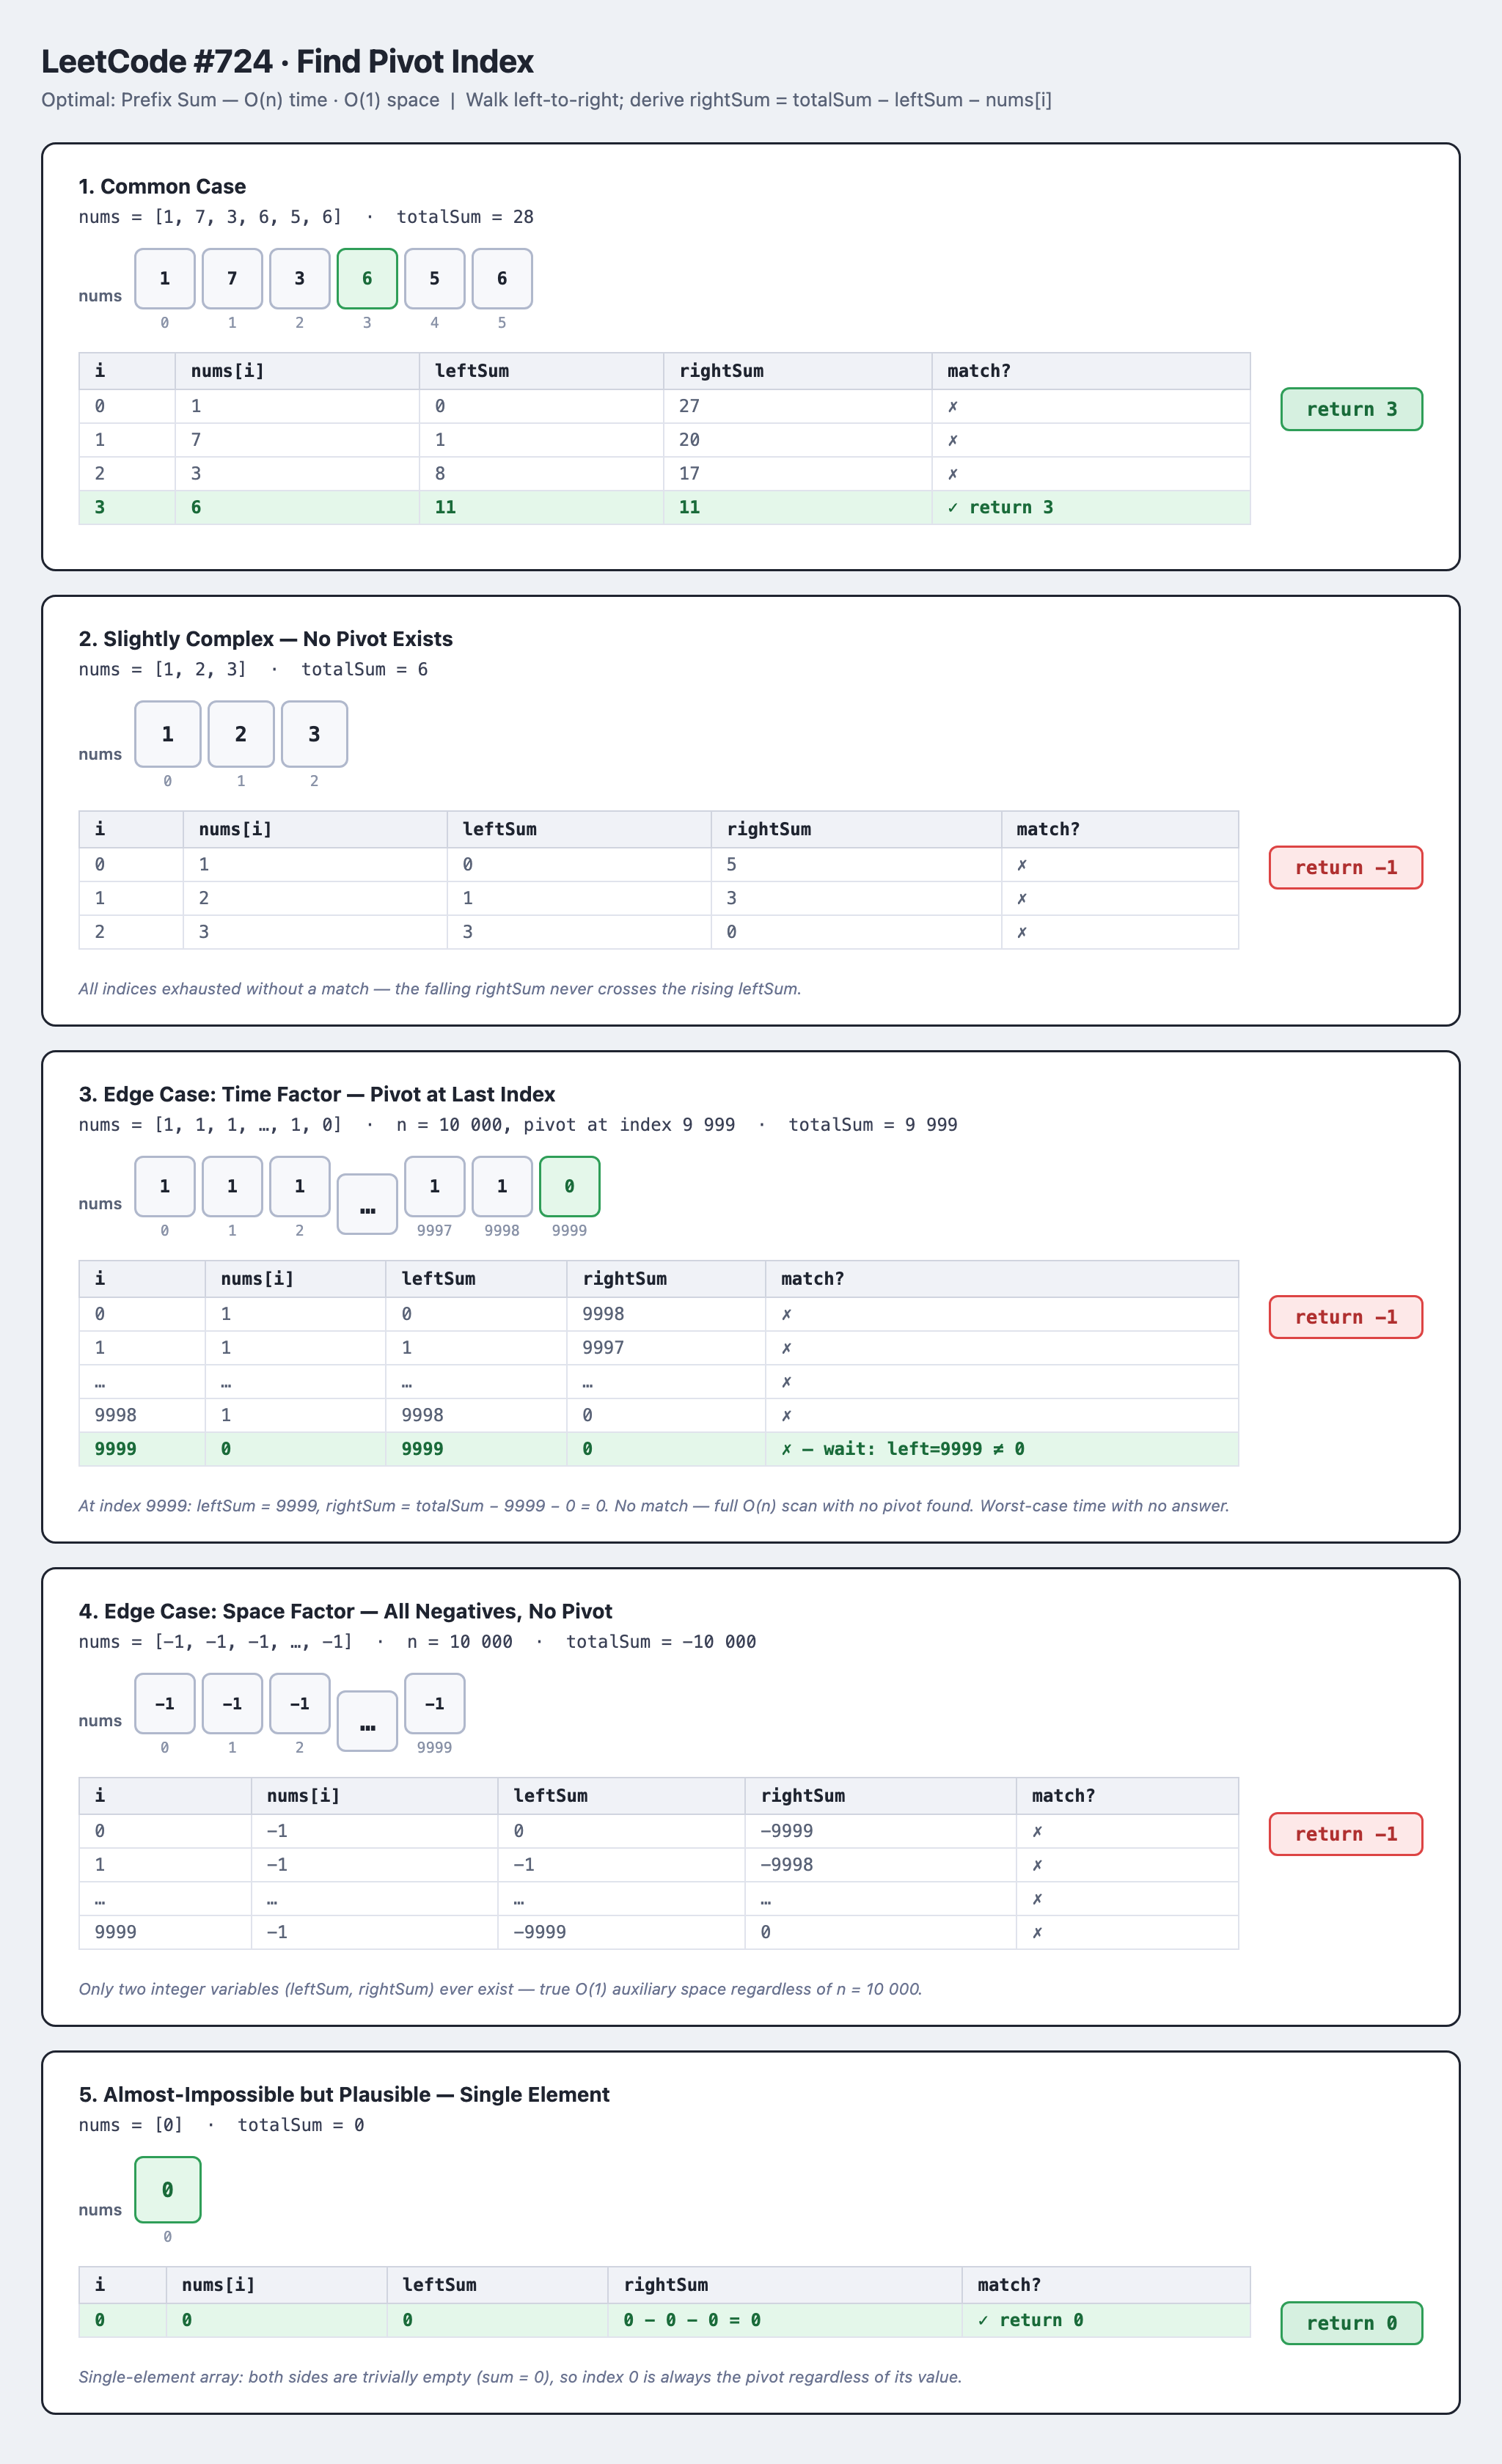